# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hotels.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. The data looks good aside from the agent and company information. Almost eveything I can see on the head is NaN, so we will have to deal with that. Also the reseration status doesn't seem to be too helpful to us.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [5]:
from sklearn.preprocessing import StandardScaler

# Add code here 🔧
features = ['lead_time', 'stays_in_week_nights', 'adr', 'total_of_special_requests']
df_subset = df[features].dropna()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_subset)

df_final = pd.DataFrame(df_scaled, columns=features)
print(df_final.head())

   lead_time  stays_in_week_nights       adr  total_of_special_requests
0   2.227051             -1.310240 -2.015038                  -0.720694
1   5.923385             -1.310240 -2.015038                  -0.720694
2  -0.907814             -0.786207 -0.530935                  -0.720694
3  -0.851667             -0.786207 -0.530935                  -0.720694
4  -0.842309             -0.262174 -0.075810                   0.540666


### ✍️ Your Response: 🔧
1. I selected lead time because it seperates people from just doing last minute and the people that plan really far ahead, stays_in_week_nights because it can tell us how long people are staying (aka if they are long term), and ADR (this is the money), and total of specail requests (separating high need people from eacy going.

2. I expect to find last minute people, planners, people on a budget, and people staying somewhere for a while.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



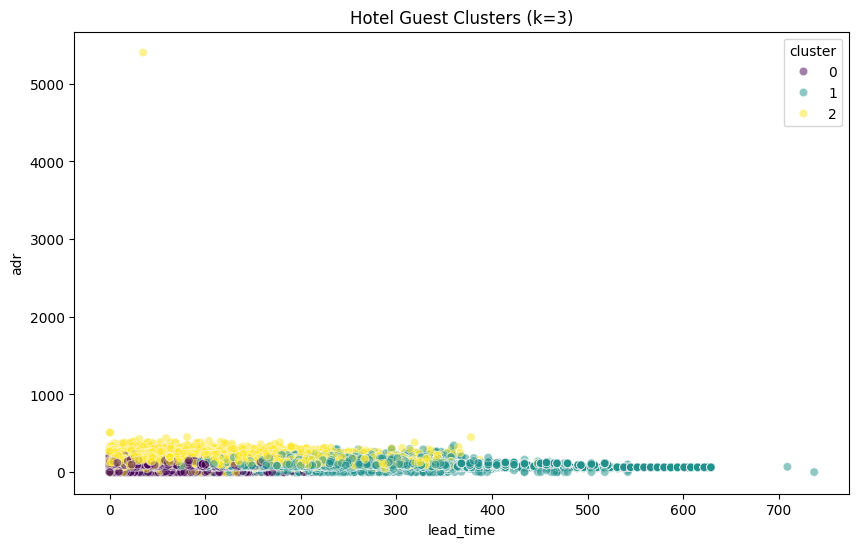

          lead_time  stays_in_week_nights         adr  \
cluster                                                 
0         46.661527              1.845203   86.718067   
1        243.874913              3.478992   90.472642   
2         75.180741              2.777019  141.444332   

         total_of_special_requests  
cluster                             
0                         0.233466  
1                         0.249512  
2                         1.523515  


In [6]:
# Add code here

from sklearn.cluster import KMeans

k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df_subset['cluster'] = model.fit_predict(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_subset, x='lead_time', y='adr', hue='cluster', palette='viridis', alpha=0.5)
plt.title(f'Hotel Guest Clusters (k={k})')
plt.show()

print(df_subset.groupby('cluster').mean())

### ✍️ Your Response: 🔧
1. I chose 3 because it is easy to read from, planners, budget people, and VIPs

2. The types of customers to show up in the clusters seems to be people on a budget, long term planners, and fancy spenders.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


GMM Soft Cluster Probabilities:
 [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]


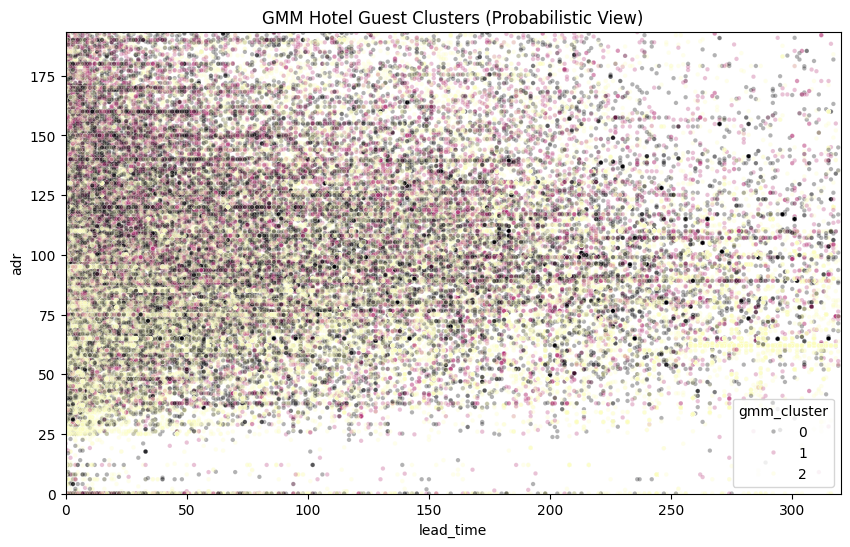


--- GMM Group Averages ---
              lead_time  stays_in_week_nights         adr  \
gmm_cluster                                                 
0             88.865992              2.549766  108.575533   
1             90.363124              3.006012  117.994581   
2            114.305262              2.360587   94.926715   

             total_of_special_requests   cluster  
gmm_cluster                                       
0                             1.000000  1.015306  
1                             2.174775  1.920236  
2                             0.000000  0.391074  


In [11]:
# Add your code here

from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
df_subset['gmm_cluster'] = gmm.fit_predict(df_scaled)

probs = gmm.predict_proba(df_scaled)
print("GMM Soft Cluster Probabilities:\n", probs[:5].round(3))

q_lead = df_subset['lead_time'].quantile(0.95)
q_adr = df_subset['adr'].quantile(0.95)
df_plot_gmm = df_subset[(df_subset['lead_time'] < q_lead) & (df_subset['adr'] < q_adr)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot_gmm, x='lead_time', y='adr', hue='gmm_cluster',
                palette='magma', s=10, alpha=0.3)

plt.title('GMM Hotel Guest Clusters (Probabilistic View)')
plt.xlim(0, q_lead)
plt.ylim(0, q_adr)
plt.show()

print("\n--- GMM Group Averages ---")
print(df_subset.groupby('gmm_cluster').mean())

### ✍️ Your Response: 🔧
1. The GMM means are way harder to look at and read, since everything is everywhere it doesn't make much sense.

2. This could help the marketing people see if people are on the fence between groups and decide weather or not to send them marketing material.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [13]:
# Add code here 🔧

from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

df_sample = df_subset.sample(10000, random_state=42)

scaled_sample = scaler.transform(df_sample[features])

kmeans_labels = model.predict(scaled_sample)
gmm_labels = gmm.predict(scaled_sample)


results = {
    'Metric': ['WCSS (Inertia)', 'Silhouette Score', 'Davies-Bouldin Index'],
    'K-Means': [model.inertia_,
                silhouette_score(scaled_sample, kmeans_labels),
                davies_bouldin_score(scaled_sample, kmeans_labels)],
    'GMM': ['N/A',
            silhouette_score(scaled_sample, gmm_labels),
            davies_bouldin_score(scaled_sample, gmm_labels)]
}


metrics_df = pd.DataFrame(results)
print(metrics_df)

                 Metric        K-Means       GMM
0        WCSS (Inertia)  305395.715013       N/A
1      Silhouette Score       0.264691   0.17126
2  Davies-Bouldin Index       1.352885  2.116778


### ✍️ Your Response: 🔧
1. It looks like the K means did the best. At .026 and 1.352 those are the highest and lowest numbers.

2. I would recommend K means to a business analyst. there are clearer groups and it is easier to understand.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [16]:
# Add code here 🔧

cluster_analysis = df_subset.groupby('cluster')[features].mean().sort_values(by='adr')

print("--- Cluster Profiles (Sorted by Spending) ---")
print(cluster_analysis.round(2))

--- Cluster Profiles (Sorted by Spending) ---
         lead_time  stays_in_week_nights     adr  total_of_special_requests
cluster                                                                    
0            46.66                  1.85   86.72                       0.23
1           243.87                  3.48   90.47                       0.25
2            75.18                  2.78  141.44                       1.52


### ✍️ Your Response: 🔧
1. In terms of guest behavior, 0 would be short stayer (booking closer to stay time), 1 would be planning vacationer, 2 would be premium guest.

2. For 0 do last minute deals that get sent to them, for 1 send them early bird options, for 2 make something very convinient for them showing that the hotel cares.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. I think that the hardest thing about unsupervised learning is that you need to know if models are right or wrong. I think it takes more intuition than just getting a simple answer.

2. Clustering you are trying to label people as some certain type of customer, not trying to find a specific outcome like you are with supervised models.

3. Instead of trying to guess what type of customer someone is we will be able to file them into groups so we can specialize their experience.

4. I would like to bridge the gap between business analytics and real-world operations by making my own business flipping bikes and cars. Learning how to segment different listings or buyers will be very helpful.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [19]:
!jupyter nbconvert --to html "assignment_09_rosolowski_evan.ipynb"

[NbConvertApp] Converting notebook assignment_09_rosolowski_evan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 1412134 bytes to assignment_09_rosolowski_evan.html
